In [4]:
import pandas as pd
df = pd.read_parquet("../data/processed/listings_clean.parquet")

array([[<Axes: title={'center': 'Price (raw, DH)'}>,
        <Axes: title={'center': 'Price (log1p)'}>,
        <Axes: title={'center': 'Price vs Age'}, xlabel='Age (years)'>],
       [<Axes: title={'center': 'Price vs Mileage'}, xlabel='Mileage (km)'>,
        <Axes: title={'center': 'Median Price by Brand (top 10 by volume)'}>,
        <Axes: title={'center': 'price_mad'}, xlabel='is_dealer'>]],
      dtype=object)

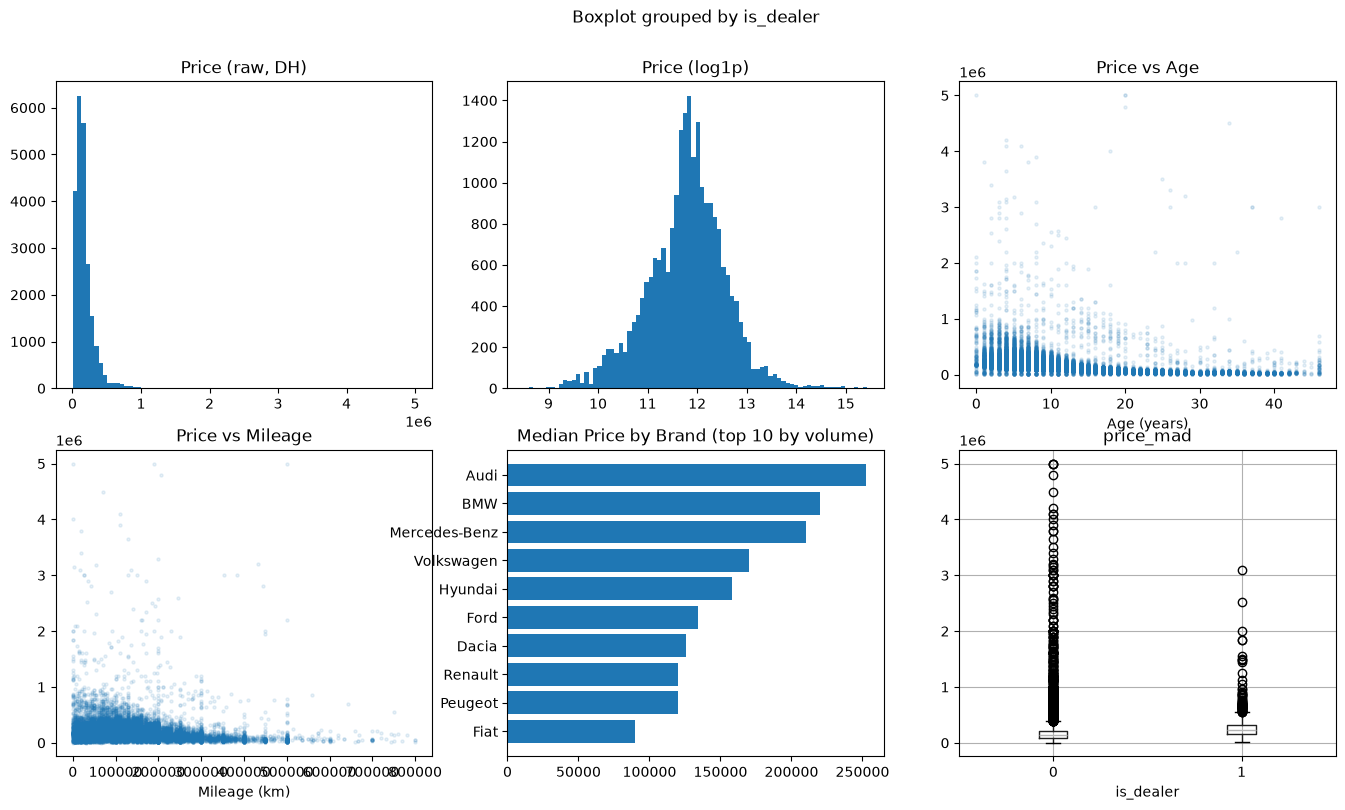

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].hist(df["price_mad"].dropna(), bins=80)
axes[0, 0].set_title("Price (raw, DH)")

axes[0, 1].hist(np.log1p(df["price_mad"].dropna()), bins=80)
axes[0, 1].set_title("Price (log1p)")

axes[0, 2].scatter(df["age"], df["price_mad"], alpha=0.1, s=5)
axes[0, 2].set_title("Price vs Age")
axes[0, 2].set_xlabel("Age (years)")

axes[1, 0].scatter(df["mileage_km"], df["price_mad"], alpha=0.1, s=5)
axes[1, 0].set_title("Price vs Mileage")
axes[1, 0].set_xlabel("Mileage (km)")

top_brands = df["brand"].value_counts().head(10).index
brand_medians = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")["price_mad"]
    .median()
    .sort_values()
)
axes[1, 1].barh(brand_medians.index, brand_medians.values)
axes[1, 1].set_title("Median Price by Brand (top 10 by volume)")

df.boxplot(column="log_price", by="is_dealer", ax=axes[1, 2])
axes

In [3]:
import os
print(os.getcwd())

c:\Users\Administrator\Desktop\Car_price_prediction\moroccan-car-prices\notebooks


In [6]:
print(df.columns.tolist())

['listing_id', 'url', 'title', 'price_mad', 'log_price', 'year', 'age', 'year_is_capped', 'mileage_km', 'km_per_year', 'mileage_was_implausible', 'fuel', 'transmission', 'city', 'city_id', 'city_freq', 'seller_type', 'is_dealer', 'is_shop', 'is_premium', 'is_urgent', 'is_highlighted', 'is_car_checked', 'n_photos', 'search_page', 'scraped_at', 'brand']
